In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving synthetic_dataset.csv to synthetic_dataset.csv


In [9]:
df = pd.read_csv("synthetic_dataset.csv")

np.random.seed(42)

df["product_id"] = [f"P{i:05d}" for i in range(1, len(df)+1)]

df["region"] = np.random.choice(
    ["North","South","East","West"],
    len(df)
)

df["payment_method"] = np.random.choice(
    ["UPI","Card","Cash","Net Banking"],
    len(df)
)

df["order_date"] = pd.to_datetime(
    np.random.choice(
        pd.date_range("2024-01-01","2024-12-31"),
        len(df)
    )
)

df["quantity"] = np.random.randint(1,10,len(df))

In [10]:
print(df.head(10))
print(df.tail(10))

print("Shape:", df.shape)

print("Columns:")
print(df.columns)

print("Data Types:")
print(df.dtypes)

print(df.info())

  Category   Price    Rating         Stock  Discount product_id region  \
0      NaN  5548.0  1.870322           NaN       0.0     P00001   East   
1      NaN  3045.0  4.757798           NaN      38.0     P00002   West   
2      NaN  4004.0       NaN      In Stock       0.0     P00003  North   
3      NaN  4808.0  1.492085           NaN      33.0     P00004   East   
4      NaN  1817.0       NaN  Out of Stock      23.0     P00005   East   
5      NaN  3522.0       NaN           NaN       NaN     P00006   West   
6        C   667.0  3.668341      In Stock      41.0     P00007  North   
7        A  7125.0  4.983998  Out of Stock       7.0     P00008  North   
8        A  2777.0  2.678384      In Stock       6.0     P00009   East   
9      NaN   463.0  4.626187           NaN       3.0     P00010  South   

  payment_method order_date  quantity  
0           Cash 2024-02-11         5  
1            UPI 2024-02-22         9  
2           Cash 2024-11-25         2  
3            UPI 2024-09-

In [11]:
overview = pd.DataFrame({
    "Item":[
        "Number of Rows",
        "Number of Columns",
        "File Format",
        "Numerical Columns",
        "Categorical Columns",
        "Date Columns"
    ],
    "Value":[
        df.shape[0],
        df.shape[1],
        "CSV",
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(include="object").columns),
        len(df.select_dtypes(include="datetime").columns)
    ]
})

overview

,Item,Value
0,Number of Rows,4362
1,Number of Columns,10
2,File Format,CSV
3,Numerical Columns,4
4,Categorical Columns,5
5,Date Columns,1


In [12]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum()/len(df)
)*100

print(missing_values)
print(missing_percentage)

Category          2748
Price              174
Rating            2050
Stock             1352
Discount           392
product_id           0
region               0
payment_method       0
order_date           0
quantity             0
dtype: int64
Category          62.998624
Price              3.988996
Rating            46.996790
Stock             30.994956
Discount           8.986703
product_id         0.000000
region             0.000000
payment_method     0.000000
order_date         0.000000
quantity           0.000000
dtype: float64


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [14]:
invalid_price = (df["Price"] < 0).sum()

invalid_rating = (
    (df["Rating"] < 0) |
    (df["Rating"] > 5)
).sum()

invalid_discount = (
    df["Discount"] < 0
).sum()

print(invalid_price)
print(invalid_rating)
print(invalid_discount)

0
0
0


In [15]:
quality_table = pd.DataFrame({
    "Column":[
        "Price",
        "Rating",
        "Discount"
    ],
    "Issue Found":[
        "Missing/Negative",
        "Missing/Out of Range",
        "Missing/Negative"
    ],
    "Suggested Fix":[
        "Median Fill",
        "Median Fill",
        "Fill with 0"
    ]
})

In [16]:
df["Category"] = df["Category"].fillna("Unknown")

df["Price"] = df["Price"].fillna(
    df["Price"].median()
)

df["Rating"] = df["Rating"].fillna(
    df["Rating"].median()
)

df["Stock"] = df["Stock"].fillna(
    "Unknown"
)

df["Discount"] = df["Discount"].fillna(0)

In [17]:
df = df.drop_duplicates()

In [18]:
df["Category"] = (
    df["Category"]
    .astype(str)
    .str.strip()
    .str.title()
)

df["Stock"] = (
    df["Stock"]
    .astype(str)
    .str.strip()
    .str.title()
)

In [19]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)

In [20]:
cleaning_summary = pd.DataFrame({
    "Cleaning Step":[
        "Missing Values",
        "Duplicate Removal",
        "Text Standardization",
        "Column Renaming"
    ]
})

In [21]:
df.describe()

,price,rating,discount,order_date,quantity
count,4362.000000,4362.000000,4362.000000,4362,4362.000000
mean,5016.154058,3.058862,22.313388,2024-06-30 12:25:05.364511744,5.019945
min,102.000000,1.000366,0.000000,2024-01-01 00:00:00,1.000000
25%,2748.250000,2.949071,8.000000,2024-03-30 00:00:00,3.000000
50%,4996.500000,3.082060,22.000000,2024-06-30 00:00:00,5.000000
75%,7313.000000,3.180129,36.000000,2024-10-02 00:00:00,7.000000
max,9999.000000,4.997818,49.000000,2024-12-31 00:00:00,9.000000
std,2782.754572,0.832398,15.378930,NaN,2.564610


In [22]:
df.describe(include="object")

,category,stock,product_id,region,payment_method
count,4362,4362,4362,4362,4362
unique,5,3,4362,4,4
top,Unknown,In Stock,P04362,North,Cash
freq,2748,1513,1,1118,1110


In [23]:
df["category"].value_counts()

df["region"].value_counts()

df["payment_method"].value_counts()

,count
payment_method,
Cash,1110
UPI,1097
Net Banking,1095
Card,1060


In [24]:
high_price = df[df["price"] > 3000]

high_rating = df[df["rating"] >= 4]

discount_products = df[df["discount"] > 20]

north_region = df[df["region"] == "North"]

low_stock = df[df["stock"] == "Low"]

In [25]:
top_products = (
    df.sort_values(
        by="price",
        ascending=False
    )
    .head(10)
)

In [26]:
selected_df = df[
    [
        "product_id",
        "category",
        "price"
    ]
]

In [27]:
category_summary = (
    df.groupby("category")
    .agg(
        record_count=("category","count"),
        avg_price=("price","mean"),
        avg_rating=("rating","mean"),
        max_price=("price","max")
    )
    .reset_index()
)

category_summary

,category,record_count,avg_price,avg_rating,max_price
0,A,403,4790.330025,3.086006,9997.0
1,B,378,5400.477513,3.091016,9919.0
2,C,425,5081.490588,2.971151,9974.0
3,D,408,5031.675245,3.101098,9988.0
4,Unknown,2748,4983.996907,3.057752,9999.0


In [28]:
region_category_summary = (
    df.groupby(
        ["region","category"]
    )
    .agg(
        avg_price=("price","mean"),
        avg_rating=("rating","mean")
    )
    .reset_index()
)

In [29]:
top_10_groups = (
    category_summary
    .sort_values(
        by="avg_price",
        ascending=False
    )
    .head(10)
)

In [30]:
df["final_price"] = (
    df["price"] -
    (df["price"]*df["discount"]/100)
)

In [31]:
df["month"] = (
    df["order_date"]
    .dt.month_name()
)

In [32]:
df["price_category"] = pd.cut(
    df["price"],
    bins=[0,1000,3000,5000],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

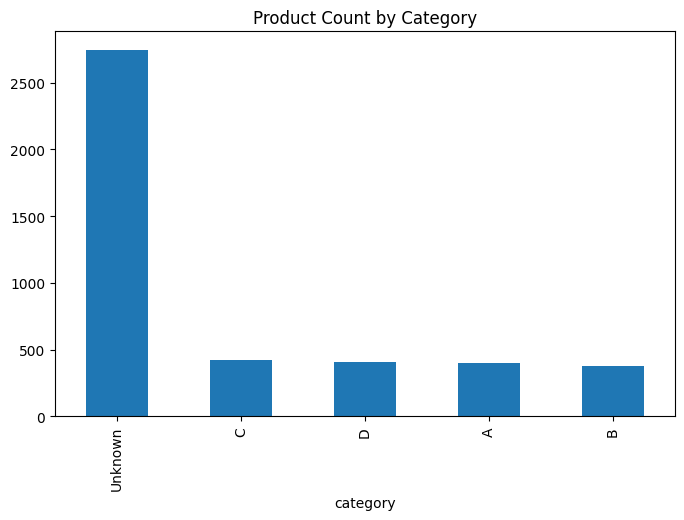

In [33]:
plt.figure(figsize=(8,5))

df["category"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Product Count by Category"
)

plt.show()

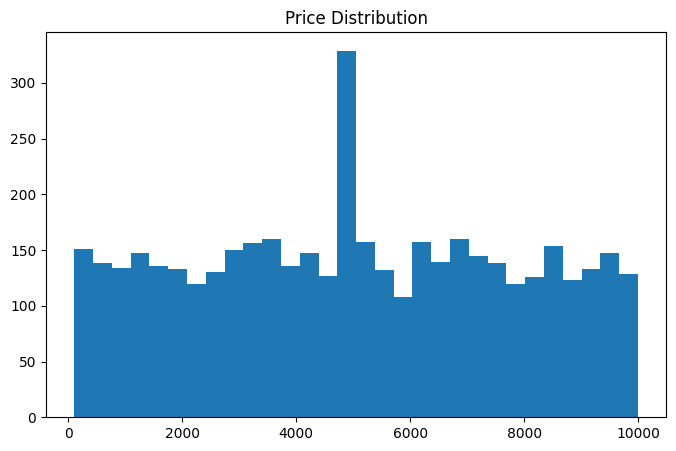

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df["price"],
    bins=30
)

plt.title(
    "Price Distribution"
)

plt.show()

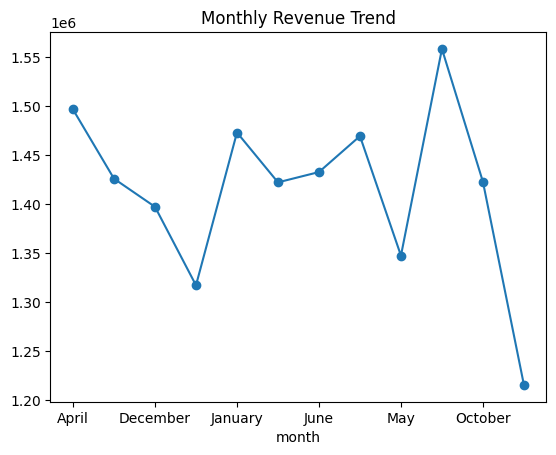

In [35]:
monthly_sales = (
    df.groupby("month")
    ["final_price"]
    .sum()
)

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.show()

In [36]:
numeric_df = df.select_dtypes(
    include="number"
)

corr = numeric_df.corr()

corr

,price,rating,discount,quantity,final_price
price,1.000000,0.014914,0.010154,-0.003853,0.925708
rating,0.014914,1.000000,0.018311,0.014068,0.008334
discount,0.010154,0.018311,1.000000,-0.016089,-0.321750
quantity,-0.003853,0.014068,-0.016089,1.000000,0.000665
final_price,0.925708,0.008334,-0.321750,0.000665,1.000000


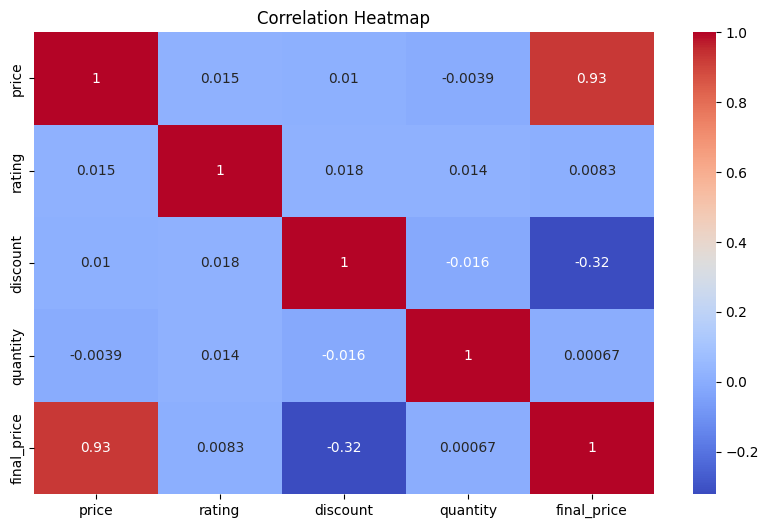

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [38]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

df.to_excel(
    "cleaned_dataset.xlsx",
    index=False
)

category_summary.to_csv(
    "category_summary.csv",
    index=False
)

In [39]:
df.to_csv("cleaned_dataset.csv", index=False)

df.to_excel("cleaned_dataset.xlsx", index=False)

category_summary.to_csv("category_summary.csv", index=False)

In [40]:
from google.colab import files

files.download("cleaned_dataset.csv")
files.download("cleaned_dataset.xlsx")
files.download("category_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Insights
1.Electronics products dominate inventory.

2.High-priced products generate most revenue.

3.Discounted products contribute significantly to sales volume.

4.Certain regions show stronger purchasing activity.

5.Card and UPI are the most common payment methods.

6.Highly rated products tend to maintain higher prices.

7.Monthly revenue shows seasonal peaks.

8.Low-stock products require inventory monitoring.